In [2]:
pip install numpy pandas matplotlib seaborn yfinance tweepy transformers datasets scikit-learn torch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 24.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 16.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.4 MB/s eta 0:00:00a 0:00:01
  Created wheel for peewee: filename=peewee-3.17.9-cp312-cp312-macosx_10_9_universal2.whl size=419187 sha256=0970eed037c99b11c04c9abc816f6a758753aec78a2096320ebd5aa964977a25
  Stored in directory: /Users/sahilgulati/Library/Caches/pip/wheels/43/ef/2d/2c51d496bf084945ffdf838b4cc8767b8ba1cc20eb41588831
Successfully built peewee
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.2.0
    Uninstalling fsspec-2025.2.0:
      Successfully uninstalled fsspec-2025.2.0
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consid

In [3]:
pip install polygon-api-client

Note: you may need to restart the kernel to use updated packages.


In [4]:
from polygon import RESTClient


API_KEY = "hxGeYKs1qclcdpNgPzniVjNvtgIcbulg"
client = RESTClient(API_KEY)

In [5]:
pip install praw

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import praw
import tweepy
from transformers import pipeline
from sklearn.ensemble import IsolationForest

In [10]:
df = pd.read_csv('/Users/sahilgulati/Desktop/Stock_Testing_vsc/Stock-testing/nasdaq-listed.csv')
print(df.head())

  Symbol                                      Security Name
0  AACBU                 Artius II Acquisition Inc. - Units
1   AACG  ATA Creativity Global - American Depositary Sh...
2   AADI               Aadi Bioscience, Inc. - Common Stock
3   AADR                AdvisorShares Dorsey Wright ADR ETF
4    AAL       American Airlines Group, Inc. - Common Stock


In [11]:
tickers_nasdaq = df['Symbol'].tolist()
print(tickers_nasdaq[0:10])

['AACBU', 'AACG', 'AADI', 'AADR', 'AAL', 'AAME', 'AAOI', 'AAON', 'AAPB', 'AAPD']


In [12]:
from datetime import date
import praw
import re
from collections import Counter

# Reddit API Setup
reddit = praw.Reddit(
    client_id="_f9G2wmqD_D-8BU7usAkuw",
    client_secret="gLt3IkPt4B-GrPV-yQ44-LUy2XXmnQ",
    user_agent="sahilprostar/1.0"
)

# Load NASDAQ tickers (assuming tickers_nasdaq is already loaded from CSV)
Subreddit = input("Enter the subreddit name (default: WallStreetBets): ") or "wallstreetbets"
subreddit_chosen = reddit.subreddit(Subreddit)
hot_posts = subreddit_chosen.hot(limit=50)

# Extract NASDAQ tickers from Reddit (Titles, Bodies, and Comments)
tickers_reddit = []

for post in hot_posts:
    # Extract tickers from post title
    words_title = re.findall(r'\b[A-Z]{2,5}\b', post.title)
    valid_tickers_title = [word for word in words_title if word in tickers_nasdaq]
    tickers_reddit.extend(valid_tickers_title)

    # Extract tickers from post body (selftext)
    if post.selftext:
        words_body = re.findall(r'\b[A-Z]{2,5}\b', post.selftext)
        valid_tickers_body = [word for word in words_body if word in tickers_nasdaq]
        tickers_reddit.extend(valid_tickers_body)

    # Extract tickers from comments
    post.comments.replace_more(limit=0)  # Load all comments
    for comment in post.comments.list():
        if comment.body:
            words_comment = re.findall(r'\b[A-Z]{2,5}\b', comment.body)
            valid_tickers_comment = [word for word in words_comment if word in tickers_nasdaq]
            tickers_reddit.extend(valid_tickers_comment)

# Count top mentioned stocks
top_stocks = Counter(tickers_reddit).most_common(10)

# Display results
print("\n📅 Date:", date.today())
print("📈📉 Top 10 Mentioned Stocks on Reddit (Titles, Bodies & Comments):")
for idx, (stock, count) in enumerate(top_stocks, 1):
    print(f"{idx}. {stock} ({count} mentions)")



📅 Date: 2025-03-12
📈📉 Top 10 Mentioned Stocks on Reddit (Titles, Bodies & Comments):
1. TSLA (356 mentions)
2. MSTR (105 mentions)
3. EU (52 mentions)
4. OP (44 mentions)
5. NVDA (39 mentions)
6. STRK (30 mentions)
7. ADBE (22 mentions)
8. TSLQ (18 mentions)
9. AMD (16 mentions)
10. RKLB (14 mentions)


In [14]:
selected_stock = input("Enter a stock ticker to analyze: ").upper()
if selected_stock in tickers_nasdaq:

    # Fetch latest news
    news = client.list_ticker_news(selected_stock, limit=3)
    for item in news:
      print(f"📰 {item.published_utc} | {item.title}\n{item.description}\n")

else:
    print("⚠️ Invalid ticker symbol.")


📰 2025-03-12T19:55:40Z | Why Super Micro Computer Stock Is Soaring Today
Supermicro stock is surging due to better-than-expected inflation data, a new cybersecurity partnership, and reports of a potential joint venture to purchase Intel's chip fabrication business.

📰 2025-03-12T18:17:09Z | Wall Street Rebounds As Cooling Inflation Draws Tech Dip Buyers: What's Driving Markets Wednesday?
Wall Street rebounded as cooling inflation data fueled expectations of Fed rate cuts, driving a rally in tech stocks led by Tesla, Nvidia, and Palantir.

📰 2025-03-12T17:52:00Z | Kessler Topaz Meltzer & Check, LLP Notifies Monolithic Power Systems, Inc. Investors of Upcoming Deadline in Securities Fraud Class Action Lawsuit
A securities class action lawsuit has been filed against Monolithic Power Systems, Inc. (MPWR) on behalf of investors who purchased or acquired the company's common stock between February 8, 2024, and November 8, 2024. The lawsuit alleges that Monolithic made false and/or misleading

MaxRetryError: HTTPSConnectionPool(host='api.polygon.io', port=443): Max retries exceeded with url: /v2/reference/news?cursor=YXA9MjAyNS0wMy0xMlQwOCUzQTAyJTNBMDBaJmFzPTIyYjhhOGQyNjM0NTY0ZWNiNzhkNWRmOTg5MzBlOTkzM2U4MGRiNmRkNDZmYTFhNmIwOTZhZjU5NmZhYzcyOTUmbGltaXQ9MyZvcmRlcj1kZXNjZW5kaW5nJnRpY2tlcj1OVkRB (Caused by ResponseError('too many 429 error responses'))

In [15]:
F_report = input("Do you want a basic fundamental report (Y/N): ").upper()
if F_report == "Y":
  fundamentals = client.get_ticker_details(selected_stock)
  print("🔍 Fundamental Analysis:")
  print(f"📌 Name: {fundamentals.name}")
  print(f"🏢 Industry: {fundamentals.sic_description}")
  print(f"💰 Market Cap: ${fundamentals.market_cap}")
  #comment


🔍 Fundamental Analysis:
📌 Name: Nvidia Corp
🏢 Industry: SEMICONDUCTORS & RELATED DEVICES
💰 Market Cap: $2805756000000.0


In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

start = '2022-12-22'
end = date.today()
stock = selected_stock

data = yf.download(stock, start, end)

# Calculate Moving Averages
EMA_50 = data['Close'].ewm(span=50, adjust=False).mean()
EMA_100 = data['Close'].ewm(span=100, adjust=False).mean()

# Calculate Moving Averages
EMA_20 = data['Close'].ewm(span=20, adjust=False).mean()
EMA_10 = data['Close'].ewm(span=10, adjust=False).mean()



YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


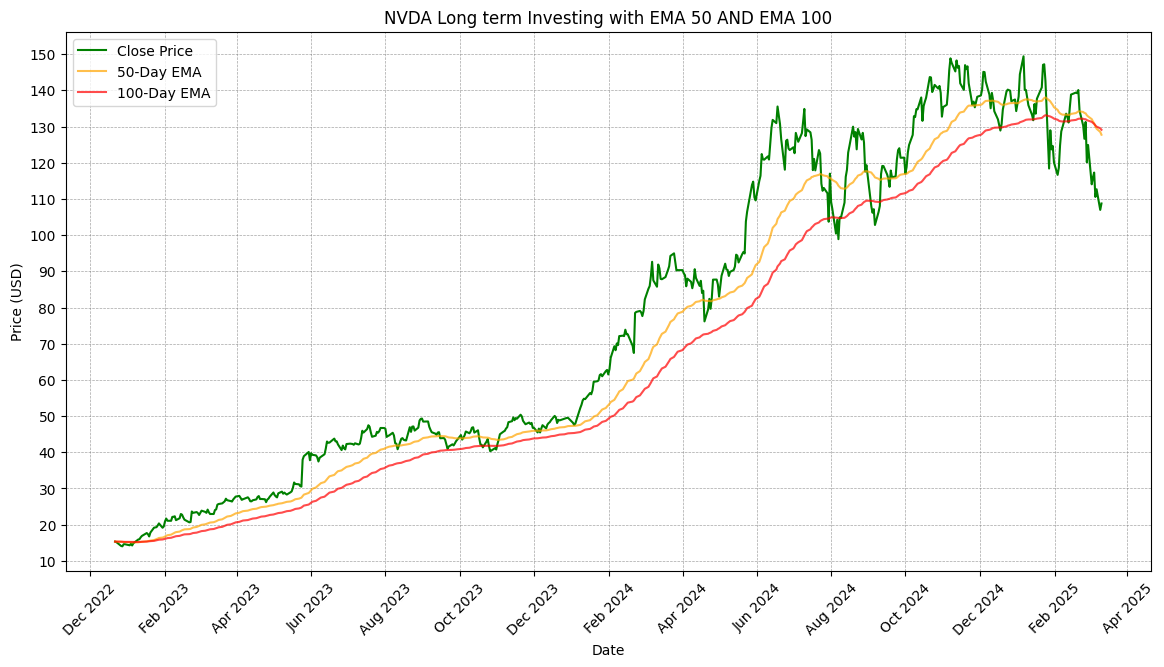

In [18]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', color='g')
plt.plot(EMA_50, label='50-Day EMA', color='orange', alpha=0.7)
plt.plot(EMA_100, label='100-Day EMA', color='r', alpha=0.7)

plt.title(f'{stock} Long term Investing with EMA 50 AND EMA 100')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Ticks at the start of each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Month Year'


# Adjust tick intervals to decrease grid box size
plt.xticks(ticks=plt.xticks()[0], rotation=45)  # Rotate x-axis labels for readability
plt.locator_params(axis='x', nbins=20)  # Increase x-axis grid density
plt.locator_params(axis='y', nbins=15)  # Increase y-axis grid density
plt.xticks(rotation=45)
plt.show()

In [19]:
# Calculate RSI
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

In [23]:
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

# Define Buy and Sell Signals based on conditions
data['Buy_Signal'] = (data['EMA_20'] > data['EMA_50']) & (data['RSI'] < 40)


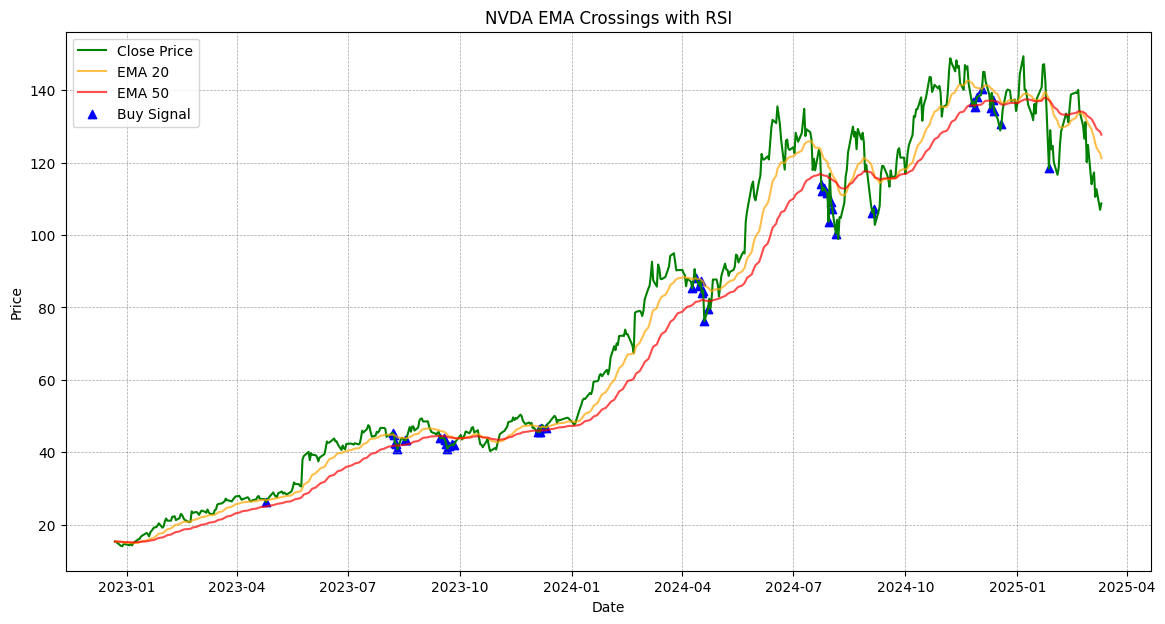

In [25]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', color='g')
plt.plot(data['EMA_20'], label='EMA 20', color='orange', alpha=0.7)
plt.plot(data['EMA_50'], label='EMA 50', color='red', alpha=0.7)

# Add buy and sell signals
plt.scatter(data.index[data['Buy_Signal']], data['Close'][data['Buy_Signal']],
            label='Buy Signal', marker='^', color='blue', alpha=1)


plt.title(f'{stock} EMA Crossings with RSI')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()


In [54]:
data = []
for t in client.vx.list_stock_financials(ticker=selected_stock,
                                         filing_date_gte='2025-01-01'):
    data.append(t)
    
print(data)
print(dir(data[0]))
print(data[0].financials)
print("Income Statement Value in USD: "+ " " + str({data[0].financials.income_statement.revenues.value}))


[StockFinancial(cik='0000320193', company_name='Apple Inc.', end_date='2024-12-28', filing_date='2025-01-31', financials=Financials(balance_sheet=BalanceSheet(assets=DataPoint(label='Assets', order=100, unit='USD', value=344085000000.0, derived_from=None, formula=None, source=None, xpath=None), current_assets=DataPoint(label='Current Assets', order=200, unit='USD', value=133240000000.0, derived_from=None, formula=None, source=None, xpath=None), cash=DataPoint(label=None, order=None, unit=None, value=None, derived_from=None, formula=None, source=None, xpath=None), accounts_receivable=DataPoint(label=None, order=None, unit=None, value=None, derived_from=None, formula=None, source=None, xpath=None), inventory=DataPoint(label='Inventory', order=230, unit='USD', value=6911000000.0, derived_from=None, formula=None, source=None, xpath=None), prepaid_expenses=DataPoint(label=None, order=None, unit=None, value=None, derived_from=None, formula=None, source=None, xpath=None), other_current_assets